<h1>M67 Gaia Star Cluster Hertzsprung Russel Diagrams (HRD)</h1>

Here are some useful links 
- [European Space Agency Gaia Mission - Writing Queries Turorial](https://www.cosmos.esa.int/web/gaia-users/archive/writing-queries)
- [Gaia's Hertzsprung-Russel Diagram](https://sci.esa.int/web/gaia/-/60198-gaia-hertzsprung-russell-diagram)
- [Measuring the Age of a Star Cluster](https://www.e-education.psu.edu/astro801/content/l7_p6.html#:~:text=The%20HR%20diagram%20for%20stage,%2D13%20billion%20years%20old)
- [Astro Prof YouTube Channel Phys 1403](https://www.youtube.com/watch?v=sDds6c7HByg)

**In the examples below we will query open clusters in the Milky way and plot it in a Hertzsprung-Russel Diagram (HRD). We will also attempt to identify Zero-order Main Sequence (ZAMS) entry points and Main Sequence Cutoff for these star clusters**

*adapted for the Python for Astronomy Course by Chandru Narayan Nov 1, 2022 using the material develped by Dr. Priya Hasan*


In [1]:
import numpy as np
import pandas as pd
import math
#from sklearn.datasets import make_blobs
#from sklearn.neighbors import NearestNeighbors
#from sklearn.cluster import DBSCAN
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

In [2]:
# import astroquery and astropy packages
import astropy.units as u
import astropy.coordinates as coord
from astroquery.gaia import Gaia
from astroquery.vizier import Vizier
from astropy import log


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
#!echo $PATH  Remove leading '#' for debugging as needed

In [4]:
# Data Folder
data_folder="data_folder"
!ls -l {data_folder}

total 1728
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04    256 Aug 12  2025 Exposure_Time.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04  34641 May 15 20:43 M45_HRD.png
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04  55360 May 15 20:21 M67_HRD.png
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04   1302 May 13 01:37 adjusted_coordinates_student_stars_2026.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04 366101 May 13 03:00 automated_M45_100000.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04 187783 May 13 03:00 automated_M67_100000.csv
drwxr-xr-x 2 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04   4096 Aug 12  2025 hyg
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04 664166 May 15 18:55 manual_m45.csv
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55

In [5]:
#!pip list  # for debugging as needed

In [6]:
#EXECUTE THIS CELL THEN RESTART KERNEL
#!pip install astroquery  # for debugging as needed
#!pip install scikit-learn # for debugging or as needed

In [7]:
# Create Access to the Gaia Database
from astroquery.gaia import Gaia

# Load Tables from the Gai Database
tables = Gaia.load_tables(only_names=True)

# Print the Table Names in the Gaia Database
#for table in tables:
#    print(table.name)

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]


In [8]:
# Get Gaia Sources Table
meta = Gaia.load_table('gaiadr3.gaia_source')
#print(meta)

In [9]:
# Print all columns in the Gaia Source Table
for column in meta.columns:
    print(column.name)

solution_id
designation
source_id
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd_frac_odd_win
ruwe
scan_direction_strength_k1
scan_di

## Open Star Cluster M45 in Orion has younger stars
![M45](../notebooks/M45.png)
## Globular Star Cluster M67 in Cancer is VERY OLD!
![M67](../notebooks/M67.png)
## The Gaia Sattelite
Gaia is a space observatory of the European Space Agency, launched in 2013 and expected to operate until 2025. The spacecraft is designed for astrometry: measuring the positions, distances and motions of stars with unprecedented precision.
Gaia  provides astrometry, photometry, and spectroscopy of more than 1000 million stars in the Milky Way. Also data for significant samples of extragalactic and Solar system objects is made available. The Gaia Archive contains deduced positions, parallaxes, proper motions, radial velocities, and brightnesses. Complementary information on multiplicity, photometric variability, and astrophysical parameters is provided for a large fraction of sources.
![gaia](gaia.png)


## Gaia Data

Gaia Data primarily contains of - Right Ascension (RA), Declination (Dec), Parallax, Radial Velocity (RV), Proper Motion in terms of Right Ascension (pmra), and Proper Motion in terms of Declination (pmdec).

1. ✅ **Right Ascension and Declination**- They are the longitude and latitude to position an object in the celestial frame of reference, or they are the celestial coordinates. They are calculated as positions in the plane of the sky. Read more about them at [https://skyandtelescope.org/astronomy-resources/right-ascension-declination-celestial-coordinates/](https://skyandtelescope.org/astronomy-resources/right-ascension-declination-celestial-coordinates/).
[(Image Source)](https://en.wikipedia.org/wiki/Right_ascension)

<img src="https://upload.wikimedia.org/wikipedia/commons/6/66/Ra_and_dec_demo_animation_small.gif" alt="RA Dec" style="width: 50%; float:center;"/> 

2. ✅ **Parallax**- The effect which causes an apparent shift in the position of an object with request to a background when observed from two different points (separated by a distance called basis) It is calculated as the semi-angle of inclination of these two different line of sights from the observation points to the object. Image source and more at: [https://en.wikipedia.org/wiki/Parallax](https://en.wikipedia.org/wiki/Parallax) 

<img src="../notebooks/Parallax_Example.png" alt="Parallax" style="width: 50%; float:center;"/>

3. ✅ **Radial Velocity**- It is the velocity of an object in a direction away from or towards the Earth (observation point). In a more general sense, it is the velocity between the object and the observation point in the direction of the radius connecting the point and the object

4. ✅ **Proper Motions (RA and Dec)**- Proper Motion is the rate of angular drift in the plane of the sky or in a transverse direction. In other words, pmra and pmdec are the rates of change of the RA and Dec of an object in the sky respectively. Their resultant is also called the transverse velocity or total proper motion. The space velocity of an object is the resultant of the transverse velocity and the radial velocity

### Gaia Data Releases

Gaia data is made publicly available through periodic data releases (DRs). Each Data Release has a richer data than the previous data release as Gaia covers the stars more times and adds new stars and objects as well. We had 3 full releases (DR1, DR2, DR3)  Data Release 3 (DR3) is the latest update. We will be working with the most recent full release, DR2. You can also try working with EDR3 with almost negligible changes to the queries we use here.


### Gaia Archive

Gaia Archive is a remote server which hosts the publicly available Dsta Releases of Gaia in the form of a database. It also provides us an interface to query the data and manipulate it according to our needs on the server itself, without us having the need to download the data first on our local computers. Using the Gaia archive site, we can get data on the positions, brightnesses, distances, and more for millions of stars and do various kinds of science and data visualization from them.

**The Gaia archive can be found here: https://gea.esac.esa.int/archive/**

### 

### Review Magnitude and Distance/Parallax Formulas (we drived these in the Star MAgnitudes Module!)
#### The quantity $\boxed{m_{app} - m_{abs}} $ OR $ \boxed {m - M} $ is known as the distance modulus
#### Note that this quantity appears in the equations below to calculate magnitudes and distance
### 1. How to calculate Magnitudes when distance (in pc) is known
#### $$ \boxed{m - M =  5 \times log_{10}(distance) - 5} $$
### 2. How to calculate Magnitudes when parallax (in arc-sec) is known
#### $$ \boxed{m - M =  5 \times log_{10}(1/parallax) - 5} $$
### 3. How to calculate Magnitudes for Gaia calculations when parallax (in milli-arc-sec or 'mas') is known
#### $$ \boxed{m -M = - 5 \times log_{10}(parallax) + 10} $$ OR $$ \boxed{M = m + 5 \times log_{10}(parallax) - 10} $$
### 4. How to calculate Distance (in pc) when apparent and absolute magnitudes are known
#### $$ \boxed{distance = 10^{\frac{m - M+5}{5}}} $$

# STEP A M67: YOU CAN SKIP THIS STEP USE FOR REFERENCE PURPOSES - START AT STEP B BELOW
## Basic Search for Manual Gaia Query and Download
Task: We will use the Basic Search in Gaia Archive to get data of a cluster M67 in 5 arcminutes radius circle around  it.  We will then read this data in Python and plot the required data.
Steps for Basic Search:

Make sure you're on the Basic query page
In the "Name" field, type in "Messier 67". It should resolve the name. 
To the right, put a "5" and then change the unit from "arc sec" to "arc min". This will tell the archive to search in a radius of 5 arcminutes around M67. There are 60 arcseconds in an arcminute, and 60 arcminutes in a degree. 
Make sure that the "Search In" drop down says "gaiadr3.gaia_source". This specifies the data we want to use is frrom source of Gaia DR3
Click "Submit Query"
You'll see a table pop up with the first 20 results from the query. At the bottom, change "VOTable" to "csv" and click "Download results". This will download a csv to your computer with the queried data in it.

In [10]:
%%html
<div style="text-align:center;">
<iframe src="https://gea.esac.esa.int/archive/" width="900" height="540"></iframe>
</div>

### Once downloaded, drag and drop downloaded file into the 'data_folder' file panel in Jupyter. 
### Rename file to 'manual_target_name.csv', for example 'manual_m67.csv'.

In [11]:
# For use with Manual Search

# Drag and drop the downloaded csv file in to the data_folder and rename to m67.csv

# import pandas
import pandas as pd

target = 'm67'
data_file = f'manual_{target}.csv'
file_path = f'{data_folder}/{data_file}'
updated_file_path = f'{data_folder}/updated_{data_file}'

# Now we can read the csv file into a pandas dataframe. 
m67 = pd.read_csv(file_path) # data_file to be found in data_folder

# Checking the top few rows of the data and the number of rows and columns
print("(Rows, Columns) =", m67.shape)
m67.head()

(Rows, Columns) = (383, 36)


,designation,source_id,ra,dec,parallax,pmra,pmdec,ruwe,phot_g_mean_mag,bp_rp,...,ebpminrp_gspphot,target_id,target_ra,target_dec,target_parallax,target_pm_ra,target_pm_dec,target_radial_velocity,epoch,target_separation (deg)
0,Gaia DR3 604917629355038848,604917629355038848,132.845425,11.813721,1.164408,-11.033650,-2.849639,0.918301,12.549206,0.734937,...,NaN,Messier 67,132.847917,11.815,1.1325,-10.9737,-2.9396,33.92,2000,0.002704
1,Gaia DR3 604917732434252032,604917732434252032,132.847881,11.818284,1.147335,-11.068406,-2.995011,1.054281,15.922245,1.215419,...,0.0429,Messier 67,132.847917,11.815,1.1325,-10.9737,-2.9396,33.92,2000,0.003297
2,Gaia DR3 604917698073552640,604917698073552640,132.842931,11.812019,0.846232,-4.910937,-3.460759,1.021133,19.975613,2.105295,...,NaN,Messier 67,132.847917,11.815,1.1325,-10.9737,-2.9396,33.92,2000,0.005670
3,Gaia DR3 604917732434325248,604917732434325248,132.845627,11.820309,1.185635,-10.656425,-3.118114,1.133236,13.152652,0.627045,...,0.0373,Messier 67,132.847917,11.815,1.1325,-10.9737,-2.9396,33.92,2000,0.005756
4,Gaia DR3 604917663714774784,604917663714774784,132.853913,11.816874,1.225815,-9.847699,-3.256775,1.158012,13.094708,0.767907,...,0.0055,Messier 67,132.847917,11.815,1.1325,-10.9737,-2.9396,33.92,2000,0.006211


## Let's practice by calculating the Absolute Magnitude of the stars in the M67 csv file we queried earlier and updating the file with it as a new column. We will perform the following steps:
### 1. Read in the 'manual_target_name.csv' file using the np.genfromtxt() method
### 2. Extract relevant columns and print to validate. Notice all the NaN
### 3. Convert array in to a Pandas DataFrame and print it, Validate column headings and values
### 4. Clean out the rows containing NaN using method dropna() and print again. Notice cleaned DF with reduced rows!
### 5. Mask for parallax>0 and update the dataframe and print to validate dataframe
### 6. Calculate the Distance using Parallax & Absolute Magnitude using distance (see cells above for formulae)
### 7. Add these as a new column to existing DF and print to validate
### 9. Write out the results as a new csv file
 

In [12]:
## DO YOUR WORK STATED ABOVE AS 5-STEPS IN THIS CELL
########################################################################
### STEP 1
########################################################################
log.info(f"Getting the DR3 results stored in {file_path}\n")
gc = np.genfromtxt(file_path, delimiter=',', names=True, dtype=None)
########################################################################
### STEP 2
########################################################################
source_id, ra, dec, parallax, pmra, pmdec, bp_rp, phot_g_mean_mag = \
gc['source_id'], gc['ra'], gc['dec'], \
gc['parallax'], gc['pmra'], gc['pmdec'], gc['bp_rp'], gc['phot_g_mean_mag']
########################################################################
### STEP 3
########################################################################
df = pd.DataFrame(gc, columns=['source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec', 'bp_rp', 'phot_g_mean_mag'])
print(df)
########################################################################
### STEP 4
########################################################################
df = df.dropna()
print(df)
########################################################################
### STEP 5
########################################################################
mask = (df['parallax']>0)
df= df[mask]
print(df)
########################################################################
### STEP 6    YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################
### When expressed in arc-sec: dist in au = 1/parallax  Type it in below
#dist = ????
dist = 1000/df['parallax']
########################################################################
### See formulas above - pick one to type in below. Abs Mag is 'M' and Apparent Mag is 'm'
### They were all derived from first principles in the python for astronomy class 
### The apparent mag from gaia is 'phot_g_mean_mag' and parallax is 'parallax'
### The log base 10 function is np.log10()
#abs_mag = ????
abs_mag = df['phot_g_mean_mag']+5*np.log10(df['parallax'])-10
########################################################################
### STEP 7 
########################################################################
df['abs_mag'] = abs_mag
df['dist'] = dist
print(df)
### STEP 9
df.to_csv(updated_file_path, index=False)

INFO: Getting the DR3 results stored in data_folder/manual_m67.csv
 [unknown]
              source_id          ra        dec  parallax       pmra     pmdec  \
0    604917629355038848  132.845425  11.813721  1.164408 -11.033650 -2.849639   
1    604917732434252032  132.847881  11.818284  1.147335 -11.068406 -2.995011   
2    604917698073552640  132.842931  11.812019  0.846232  -4.910937 -3.460759   
3    604917732434325248  132.845627  11.820309  1.185635 -10.656425 -3.118114   
4    604917663714774784  132.853913  11.816874  1.225815  -9.847699 -3.256775   
..                  ...         ...        ...       ...        ...       ...   
378  604921748227889152  132.781455  11.865691  1.123253 -11.130312 -2.955442   
379  604911478961897472  132.793112  11.752310  0.571132  -4.965345 -5.321494   
380  604916358044090624  132.911340  11.760378 -0.150271   7.407685 -6.963993   
381  604922779020241536  132.882920  11.890678  0.556035  -0.056382 -7.264780   
382  604917938592865280  132.92

# STEP B M67: Now that we have practiced doing this manually we will automate this process
## by setting up an API cone search using Gaia
## We will then use the Proper Motion  in RA and DEC to filter (mask) foreground stars
### We will then Plot all of the stars in a Hertzsprung Russell Diagram Abs Mag vs Temp (Color)

## Setup for API Gaia Target Cone Search and Download

In [13]:
# Parameters for API Query & HRD (20 minutes radius around M67 center) - Change for each query!
target = "M67" # target to query
object_radius = 1/5 * u.deg # 20 arc-min
coordinate = coord.SkyCoord.from_name(target)
print(coordinate)
num_stars = 100000 #maximum number of stars to retrieve

# Setup file paths
automated_data_file = f'automated_{target}_{num_stars}.csv'
automated_file_path = f'{data_folder}/{automated_data_file}'
print(automated_file_path)

<SkyCoord (ICRS): (ra, dec) in deg
    (132.846, 11.814)>
data_folder/automated_M67_100000.csv


In [14]:
# Query Gaia
query_sub = f"""
    source_id, ra, dec, parallax, pmra, pmdec, bp_rp, phot_g_mean_mag,  
    phot_g_mean_mag+5*log10(parallax)-10 as amg, 1000/parallax as dist
    FROM gaiaedr3.gaia_source 
    WHERE parallax>0 AND bp_rp > -0.75 AND bp_rp < 2 AND 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {coordinate.ra.value}, {coordinate.dec.value}, {object_radius.value})
    )
""" 

query_full = f"""
    source_id, ra, dec, parallax, pmra, pmdec, bp_rp, phot_g_mean_mag
    FROM gaiaedr3.gaia_source 
    WHERE 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {coordinate.ra.value}, {coordinate.dec.value}, {object_radius.value})
    )
""" 

#query = f" SELECT TOP {query_size} {query_full}"
query = f" SELECT {query_full}"

print(query)

try:
    log.info(f"Getting the DR3 results stored in {automated_file_path}\n")
    
    #gc = np.recfromcsv(automated_file_path)
    gc = np.genfromtxt(automated_file_path, delimiter=',', names=True, dtype=None)
    source_id, ra, dec, parallax, pmra, pmdec, bp_rp, phot_g_mean_mag = \
    gc['source_id'], gc['ra'], gc['dec'], \
    gc['parallax'], gc['pmra'], gc['pmdec'], gc['bp_rp'], gc['phot_g_mean_mag']
    
    print(f"reading results from previously existng {automated_data_file}\n")
    #print(ra, dec, plx, amg, dist)
    df = pd.DataFrame({"source_id": source_id, "ra": ra, "dec": dec, "parallax": parallax, "pmra": pmra, "pmdec": pmdec, "bp_rp": bp_rp, "phot_g_mean_mag": phot_g_mean_mag})
    

except OSError:
    log.info(f"Performing new query from Gaia as previous query {automated_data_file} does not exist\n")

    Gaia.ROW_LIMIT = -1
    job = Gaia.launch_job_async(query, dump_to_file=True, output_format="csv",
                                 output_file=automated_file_path)
    print(job)
    r = job.get_results()
    df = r.to_pandas()


 SELECT 
    source_id, ra, dec, parallax, pmra, pmdec, bp_rp, phot_g_mean_mag
    FROM gaiaedr3.gaia_source 
    WHERE 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', 132.846, 11.814, 0.2)
    )

INFO: Getting the DR3 results stored in data_folder/automated_M67_100000.csv
 [unknown]
reading results from previously existng automated_M67_100000.csv



In [15]:
#################################################################################
### STEP     USES FORMULAS STATED ABOVE. DERIVED IN python for astronomy SEMINAR
#################################################################################
# Add the calculated columns abs_mag and dist to dataframe.
########################################################################
df['abs_mag'] = df['phot_g_mean_mag']+5*np.log10(df['parallax'])-10
df['dist'] = 1000/df['parallax']
df

/opt/tljh/user/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,source_id,ra,dec,parallax,pmra,pmdec,bp_rp,phot_g_mean_mag,abs_mag,dist
0,604896979152355712,132.935626,11.641394,0.554218,-2.809451,1.214248,2.008558,19.627160,8.345562,1804.345334
1,604897387178485120,132.934848,11.672803,NaN,NaN,NaN,0.652632,21.049328,NaN,NaN
2,604897391469230976,132.942363,11.674436,-1.470555,1.158239,-2.550627,0.663675,20.557373,NaN,-680.015382
3,604897696411104256,132.824463,11.627224,1.089059,-10.827579,-2.877660,1.609957,17.047773,7.233030,918.224061
4,604903125249784320,132.987778,11.674151,-0.030520,-3.013822,-2.463620,0.888460,18.409786,NaN,-32765.118188
...,...,...,...,...,...,...,...,...,...,...
1469,604969718719901696,132.737725,11.947414,1.138912,-10.691396,-2.869787,0.917783,14.778589,5.061040,878.031000
1470,604969783143323904,132.725179,11.940853,-0.193473,5.276419,-6.180950,1.733048,19.609970,NaN,-5168.686184
1471,604969787437701760,132.729418,11.954399,0.733103,-11.635283,-3.162820,2.477091,19.421598,8.747422,1364.065663
1472,604969989301673728,132.675443,11.921280,1.001183,1.139620,1.871255,1.585108,20.491589,10.494156,998.818488


In [16]:
## save the ASCII table as a pandas dataframe
all_stars = df
type(all_stars)
print(all_stars)

               source_id          ra        dec  parallax       pmra  \
0     604896979152355712  132.935626  11.641394  0.554218  -2.809451   
1     604897387178485120  132.934848  11.672803       NaN        NaN   
2     604897391469230976  132.942363  11.674436 -1.470555   1.158239   
3     604897696411104256  132.824463  11.627224  1.089059 -10.827579   
4     604903125249784320  132.987778  11.674151 -0.030520  -3.013822   
...                  ...         ...        ...       ...        ...   
1469  604969718719901696  132.737725  11.947414  1.138912 -10.691396   
1470  604969783143323904  132.725179  11.940853 -0.193473   5.276419   
1471  604969787437701760  132.729418  11.954399  0.733103 -11.635283   
1472  604969989301673728  132.675443  11.921280  1.001183   1.139620   
1473  604970539060833152  132.716384  11.958751       NaN        NaN   

         pmdec     bp_rp  phot_g_mean_mag    abs_mag          dist  
0     1.214248  2.008558        19.627160   8.345562   1804.345334

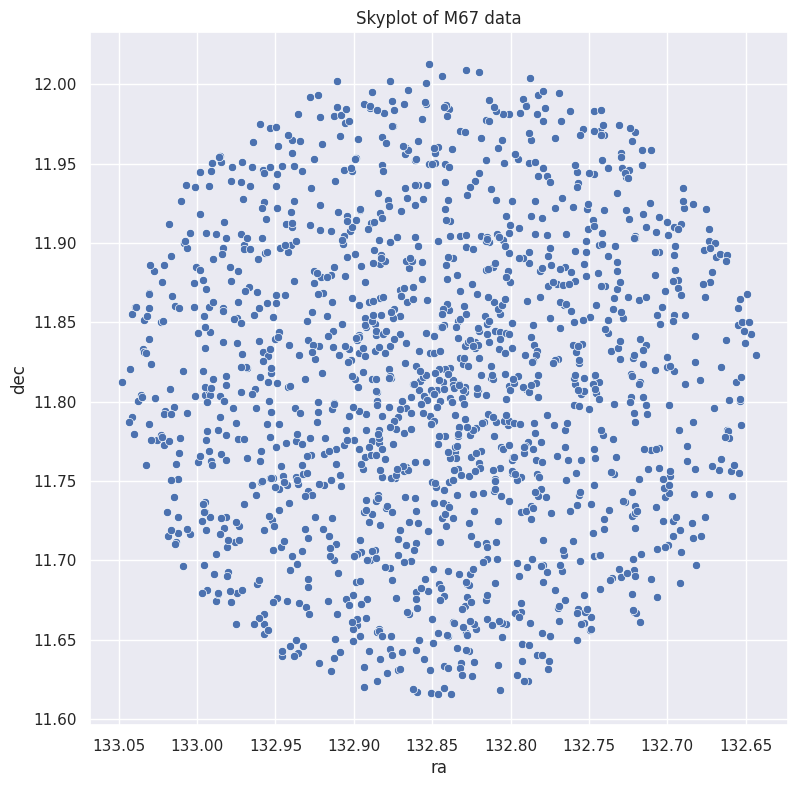

In [17]:
## plotting the skyplot 

#fig, axs = plt.subplots(1)
#plt.margins(0.005, tight=True)
#axs.set_aspect('equal')
sns.set(rc={'figure.figsize':(9,9)})
skyplot = sns.scatterplot(x='ra', y='dec', data = all_stars)
#skyplot = sns.scatterplot(x='ra', y='dec', data = members)
skyplot.invert_xaxis()
plt.title('Skyplot of ' + target + ' data')
plt.show()

########################################################################
### QUESTION     WHY IS THIS CIRCULAR ????
########################################################################

/tmp/ipykernel_16245/834460252.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='phot_g_mean_mag',palette='RdYlGn',


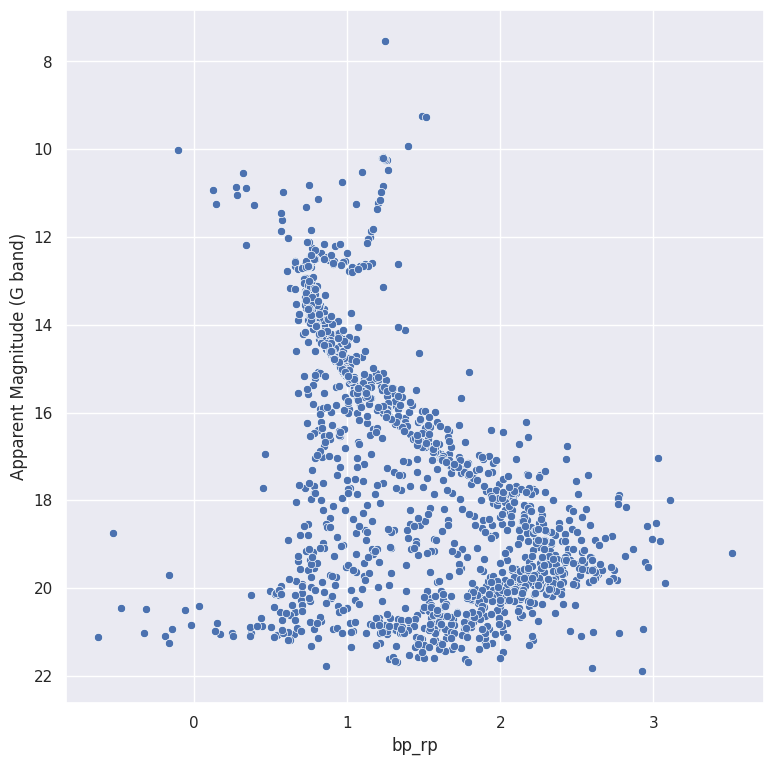

In [18]:
########################################################################
### STEP     PLOT YOUR OPEN CLUSTER'S HRD - YOUR FIRST !!!
### QUESTION I SEE THE MAIN SEQUENCE - WHAT IS ALL THAT OTHER CRAP ? pardon my french ...
########################################################################
sns.scatterplot(x = 'bp_rp', y='phot_g_mean_mag',palette='RdYlGn',
                data = all_stars)
plt.ylabel('Apparent Magnitude (G band)')
#plt.xlim(0,3)
#sns.scatterplot(hr.b_v+0.5, hr.V+10)

plt.gca().invert_yaxis()

<Axes: xlabel='pmra', ylabel='pmdec'>

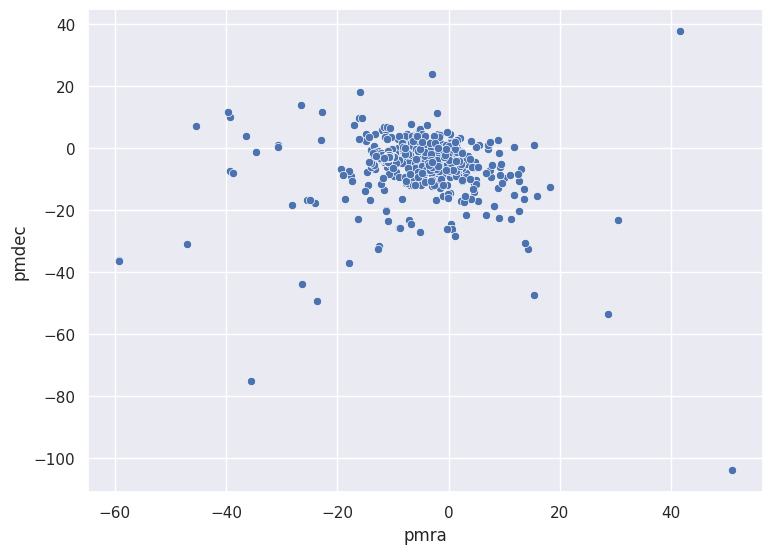

In [19]:
########################################################################
### STEP     LET'S ELIMINATE ANY STARS NOT BELONGING TO M67 !!!
###          BY ANALYZING WITH MORE PLOTS WITH PROPER MOTIONS
### QUESTION WHAT DO YOU SEE ?
########################################################################
import seaborn as sns
sns.set(rc={'figure.figsize':(8.7,6.27)})

#sns.scatterplot(x='pmra', y='pmdec', data=features[features.labels > -1], hue='labels',legend='full')

sns.scatterplot(x='pmra', y='pmdec', data=all_stars)

<Axes: xlabel='pmra', ylabel='pmdec'>

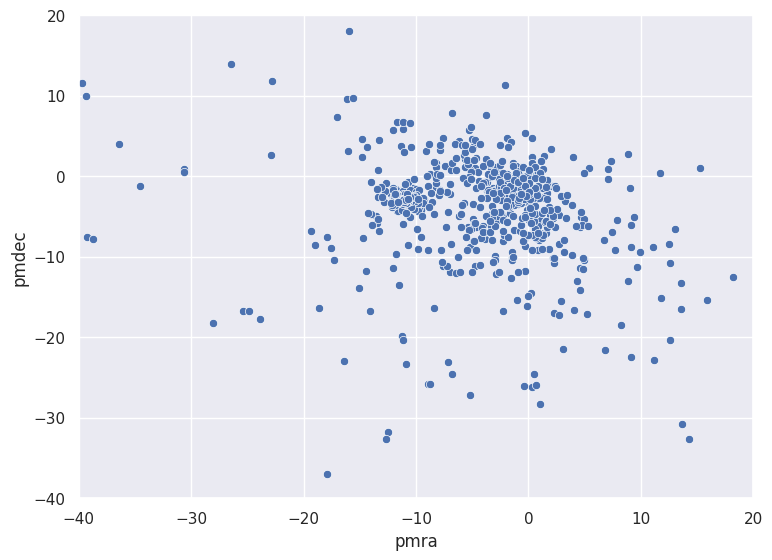

In [20]:
########################################################################
### STEP     LET'S ZOOM IN WHERE THERE ARE STARS
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################         
### QUESTION WHAT DO YOU SEE ?
########################################################################
# limit ranges to zoom in
plt.xlim(-40,20)
plt.ylim(-40,20)
sns.scatterplot(x='pmra', y='pmdec', data=all_stars)

(-20.0, 10.0)

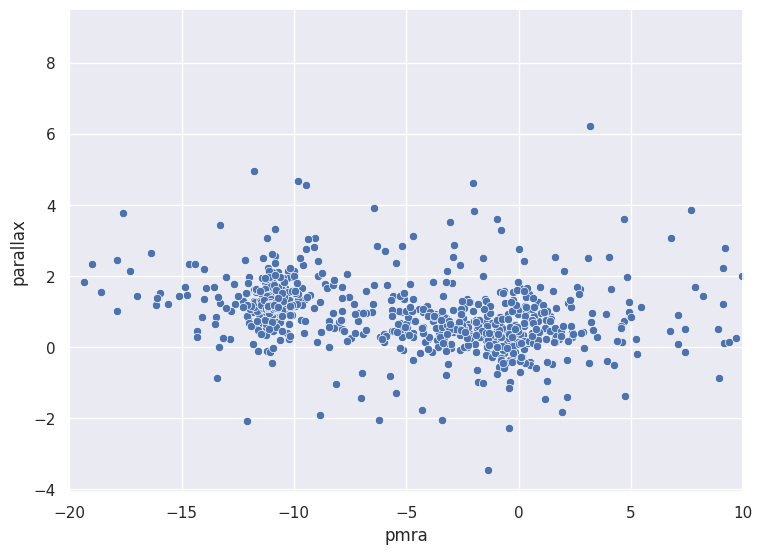

In [21]:
########################################################################
### STEP     LET'S LOOK AT IT A DIFFERENT WAY
###          BY PLOTTING PARALLAX AGAINST PMRA
###          ALSO ZOOM IN!!
########################################################################
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################            
### QUESTION WHAT DO YOU SEE ?
########################################################################
sns.scatterplot(x='pmra', y='parallax', data=all_stars)
plt.xlim([-20, 10])

(-20.0, 10.0)

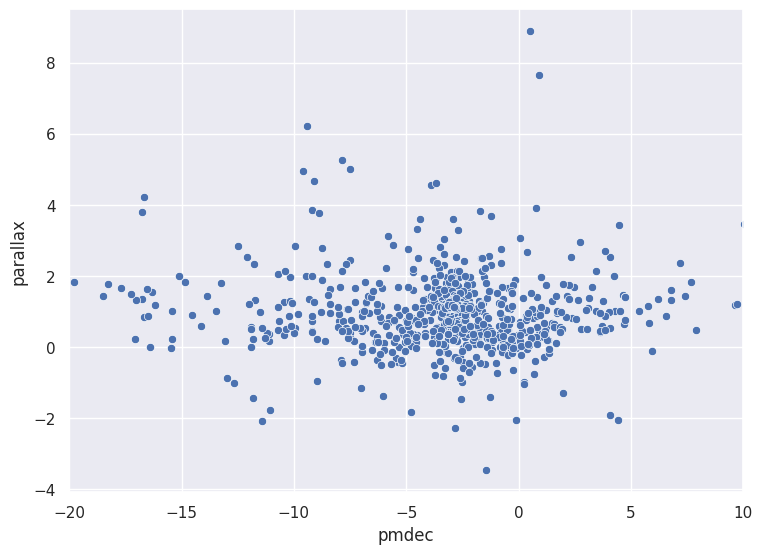

In [22]:
########################################################################
### STEP     LET'S LOOK AT IT A DIFFERENT WAY
###          BY PLOTTING PARALLAX AGAINST PMDEC
###          ALSO ZOOM IN!!
########################################################################
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################    
sns.scatterplot(x='pmdec', y='parallax', data=all_stars)
plt.xlim([-20,10])

/tmp/ipykernel_16245/1186016153.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


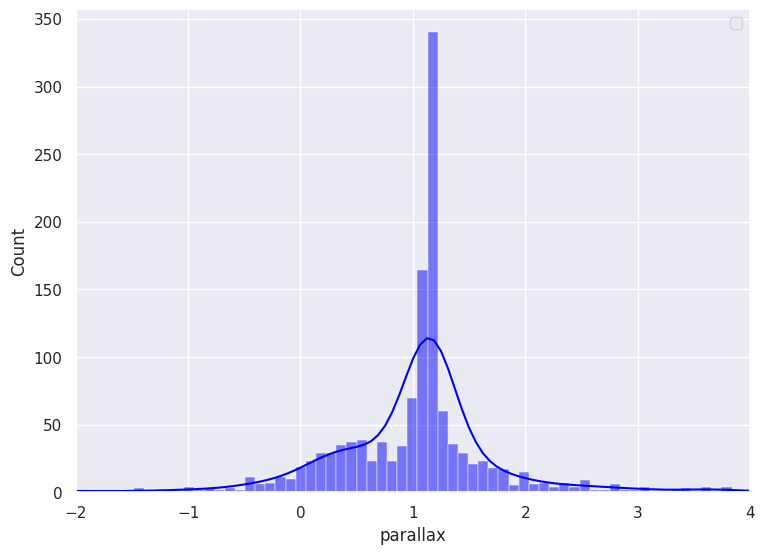

In [23]:
########################################################################
### STEP     LET'S LOOK AT IT A DIFFERENT WAY
###          BY PLOTTING HISTOGRAM OF PARALLAX
########################################################################
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################   
sns.histplot(x='parallax', data=all_stars,
              kde=True,color='blue')

plt.xlim([-2,4])
plt.legend()
plt.show()

/tmp/ipykernel_16245/4284300973.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


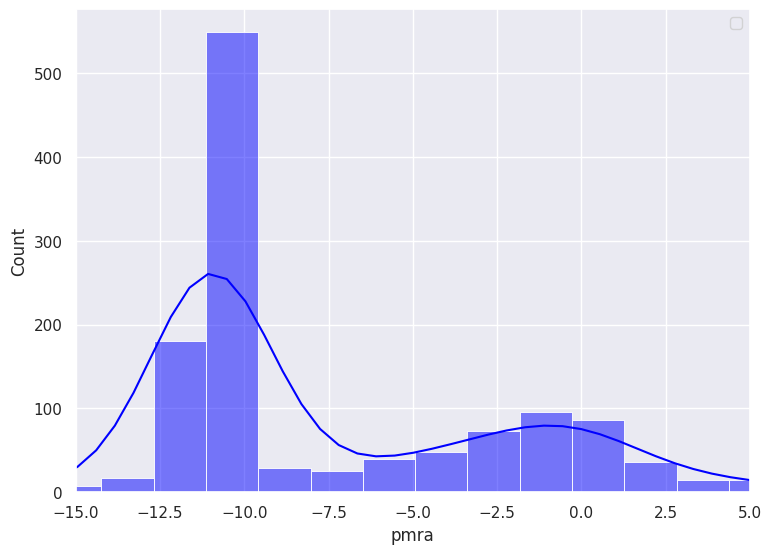

In [24]:
########################################################################
### STEP     LET'S LOOK AT IT A DIFFERENT WAY
###          BY PLOTTING HISTOGRAM OF PMRA
########################################################################
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################  
sns.histplot(x='pmra', data=all_stars,
              kde=True,color='blue')
plt.xlim([-15,5])
plt.legend()
plt.show()

### <div class="alert alert-info"><bold>It looks like our cluster is between ```pmra``` xlimits ```-15 and -8``` !!!</bold></div>

/tmp/ipykernel_16245/3370538588.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


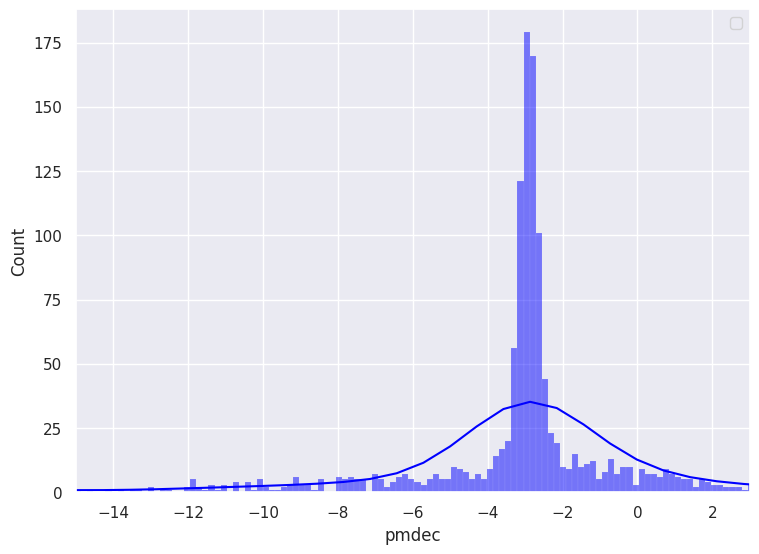

In [25]:
########################################################################
### STEP     LET'S LOOK AT IT A DIFFERENT WAY
###          BY PLOTTING HISTOGRAM OF PMDEC
########################################################################
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################  
########################################################################
### STEP     LET'S LOOK AT IT A DIFFERENT WAY
###          BY PLOTTING HISTOGRAM OF PMDEC
########################################################################
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################  
sns.histplot(x='pmdec', data=all_stars,
              kde=True,color='blue')
plt.xlim([-15,3])
plt.legend()
plt.show()

### <div class="alert alert-warning"><bold>We did not learn much from this chart</bold></div>

In [26]:
all_stars.describe()

,source_id,ra,dec,parallax,pmra,pmdec,bp_rp,phot_g_mean_mag,abs_mag,dist
count,1.474000e+03,1474.000000,1474.000000,1290.000000,1290.000000,1290.000000,1454.000000,1474.000000,1203.000000,1290.000000
mean,6.049198e+17,132.848505,11.811065,1.066847,-7.544643,-3.796300,1.400853,17.378546,6.651422,305.341284
std,1.799605e+13,0.094305,0.094316,0.892172,7.328038,6.648495,0.626528,2.898943,2.905510,16695.408752
min,6.048962e+17,132.643306,11.615911,-3.469251,-59.218205,-103.970995,-0.626070,7.543855,-2.607483,-271765.190205
25%,6.049103e+17,132.780025,11.741231,0.721332,-11.067285,-3.334795,0.855641,15.070890,4.314114,746.574849
50%,6.049174e+17,132.846324,11.810970,1.132474,-10.758292,-2.911743,1.294713,17.851591,6.375801,869.179740
75%,6.049216e+17,132.918867,11.883834,1.214957,-2.599185,-2.454075,1.914976,19.940193,8.845925,1042.907174
max,6.049719e+17,133.047979,12.012851,8.886460,50.905778,37.715878,3.512066,21.901808,14.885956,223489.189590


In [27]:
all_stars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        1474 non-null   int64  
 1   ra               1474 non-null   float64
 2   dec              1474 non-null   float64
 3   parallax         1290 non-null   float64
 4   pmra             1290 non-null   float64
 5   pmdec            1290 non-null   float64
 6   bp_rp            1454 non-null   float64
 7   phot_g_mean_mag  1474 non-null   float64
 8   abs_mag          1203 non-null   float64
 9   dist             1290 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 115.3 KB


In [28]:
########################################################################
### STEP     CREATE A MASK BY SETTING LIMITS FOR all_stars DATAFRAME
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################  
mask = (all_stars.parallax >= -2) & (all_stars.parallax <= 4) & \
    (all_stars.pmra >= -15) & (all_stars.pmra <= -8) & \
    (all_stars.pmdec >= -8) & (all_stars.pmdec <= 1)  


In [29]:
########################################################################
### STEP     CALCULATE THE ABS MAG FOR all_stars IN DATAFRAME
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################  
abs_mag = all_stars['phot_g_mean_mag']+5*np.log10(all_stars['parallax'])-10
print(abs_mag)

0        8.345562
1             NaN
2             NaN
3        7.233030
4             NaN
          ...    
1469     5.061040
1470          NaN
1471     8.747422
1472    10.494156
1473          NaN
Length: 1474, dtype: float64


/opt/tljh/user/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [30]:
########################################################################
### STEP     ADD THE ABS MAG TO THE all_stars DATAFRAME
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
########################################################################   
all_stars['abs_mag']=abs_mag

In [31]:
########################################################################
### STEP     APPLY MASK YOU CREATED all_stars DATAFRAME SAVE IN members
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
######################################################################## 
members = all_stars[mask]

In [32]:
members.describe()
members.info()

<class 'pandas.core.frame.DataFrame'>
Index: 748 entries, 3 to 1471
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        748 non-null    int64  
 1   ra               748 non-null    float64
 2   dec              748 non-null    float64
 3   parallax         748 non-null    float64
 4   pmra             748 non-null    float64
 5   pmdec            748 non-null    float64
 6   bp_rp            746 non-null    float64
 7   phot_g_mean_mag  748 non-null    float64
 8   abs_mag          741 non-null    float64
 9   dist             748 non-null    float64
dtypes: float64(9), int64(1)
memory usage: 64.3 KB


In [33]:
print(members)

               source_id          ra        dec  parallax       pmra  \
3     604897696411104256  132.824463  11.627224  1.089059 -10.827579   
5     604903125251398144  132.993638  11.681076  0.400699 -10.300305   
10    604906737317927296  133.029729  11.823727  1.157004 -10.852098   
11    604908008628339200  132.775707  11.636686  1.803000 -10.928832   
13    604909657895767680  132.829307  11.671027  1.172530 -11.074904   
...                  ...         ...        ...       ...        ...   
1463  604924737525369344  132.867886  11.987377  1.380498 -10.696496   
1464  604943880195096320  133.001679  11.935279  1.169332 -11.159537   
1467  604969306401373824  132.711161  11.925386  1.196170 -10.893533   
1469  604969718719901696  132.737725  11.947414  1.138912 -10.691396   
1471  604969787437701760  132.729418  11.954399  0.733103 -11.635283   

         pmdec     bp_rp  phot_g_mean_mag    abs_mag         dist  
3    -2.877660  1.609957        17.047773   7.233030   918.224061  

In [34]:
members_clean = members.dropna()
print(members_clean)

               source_id          ra        dec  parallax       pmra  \
3     604897696411104256  132.824463  11.627224  1.089059 -10.827579   
5     604903125251398144  132.993638  11.681076  0.400699 -10.300305   
10    604906737317927296  133.029729  11.823727  1.157004 -10.852098   
11    604908008628339200  132.775707  11.636686  1.803000 -10.928832   
13    604909657895767680  132.829307  11.671027  1.172530 -11.074904   
...                  ...         ...        ...       ...        ...   
1463  604924737525369344  132.867886  11.987377  1.380498 -10.696496   
1464  604943880195096320  133.001679  11.935279  1.169332 -11.159537   
1467  604969306401373824  132.711161  11.925386  1.196170 -10.893533   
1469  604969718719901696  132.737725  11.947414  1.138912 -10.691396   
1471  604969787437701760  132.729418  11.954399  0.733103 -11.635283   

         pmdec     bp_rp  phot_g_mean_mag    abs_mag         dist  
3    -2.877660  1.609957        17.047773   7.233030   918.224061  

/tmp/ipykernel_16245/3497569319.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='phot_g_mean_mag',palette='RdYlGn',
/tmp/ipykernel_16245/3497569319.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='phot_g_mean_mag',palette='RdYlGn',


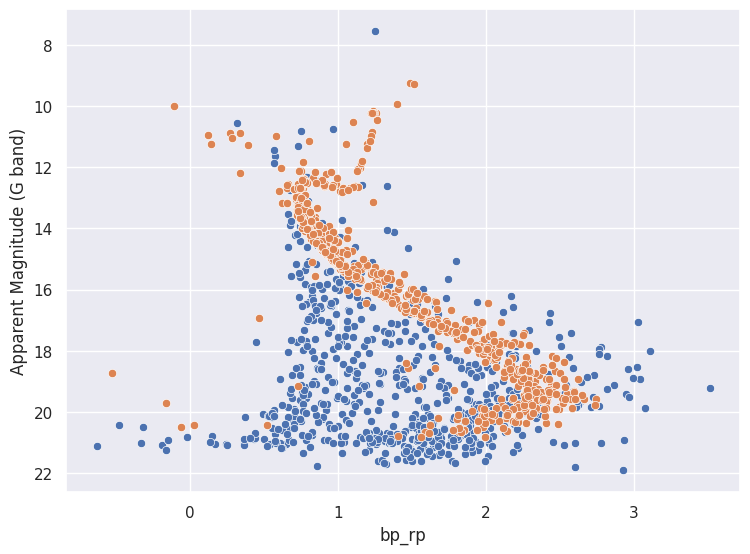

In [35]:
########################################################################
### STEP     PLOT HRD FOR members AND all_stars in 2 colors
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
######################################################################## 
sns.scatterplot(x = 'bp_rp', y='phot_g_mean_mag',palette='RdYlGn',
                data = all_stars)
sns.scatterplot(x = 'bp_rp', y='phot_g_mean_mag',palette='RdYlGn',
                data = members_clean)
plt.ylabel('Apparent Magnitude (G band)')
#plt.xlim(0,3)
#sns.scatterplot(hr.b_v+0.5, hr.V+10)

plt.gca().invert_yaxis()

/tmp/ipykernel_16245/3971993051.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',
/tmp/ipykernel_16245/3971993051.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',


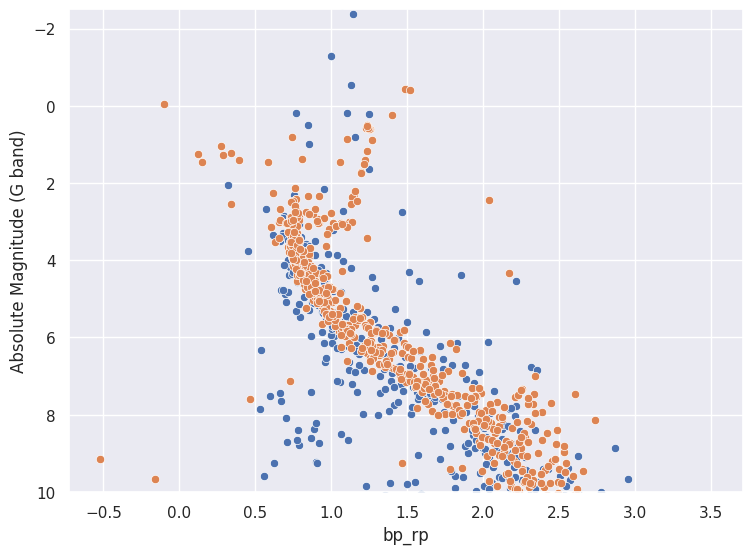

In [36]:
########################################################################
### STEP     PLOT HRD FOR all_stars & members USING ABSOLUTE MAGNITUDE VS BP_RP
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
######################################################################## 
sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',
                data = all_stars)
sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',
                data = members_clean)
plt.ylabel('Absolute Magnitude (G band)')
#plt.xlim(0,3)
plt.ylim(-2.5,10)
#sns.scatterplot(hr.b_v+0.5, hr.V+10)

plt.gca().invert_yaxis()

/tmp/ipykernel_16245/1648342595.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',


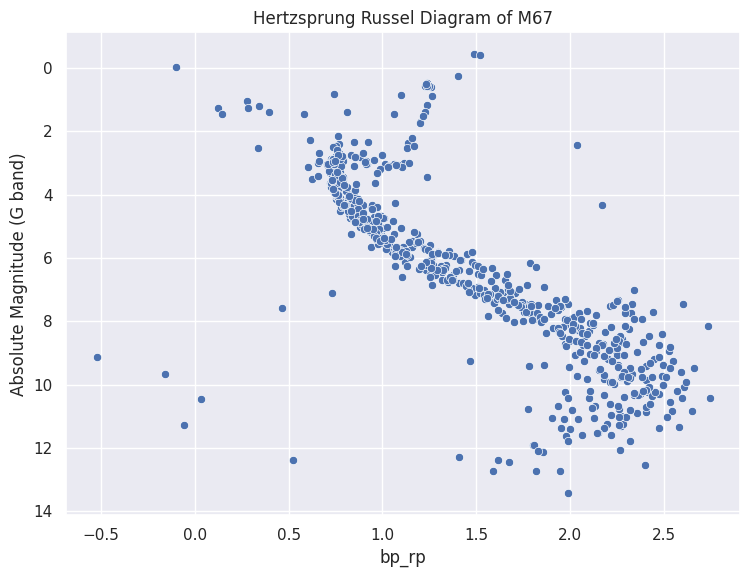

In [38]:
########################################################################
### STEP     PLOT HRD FOR members only USING ABSOLUTE MAGNITUDE VS BP_RP
### STEP     YOUR INPUTS ARE NEEDED HERE WHERE YOU SEE ???? !!!
######################################################################## 
sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',
                data = members)
plt.ylabel('Absolute Magnitude (G band)')
#plt.xlim(0,3)
#sns.scatterplot(hr.b_v+0.5, hr.V+10)
plt.gca().invert_yaxis()
plt.title('Hertzsprung Russel Diagram of ' + target)
out_file="{}/{}_HRD.png".format(data_folder,target)
plt.savefig(out_file)

## Can you tell where the Main Sequence Turnoff is happening?
## What does that tell you about the Age of the cluster?
## [This excellent article describes it all - PLEASE READ!](https://courses.ems.psu.edu/astro801/content/l7_p6.html)
![age_turnoff_point.png](../notebooks/age_turnoff_point.png)
## Answer Questions below

## What is the turnoff Point (Oldest Star still on the Main Sequence) for Open Cluster M67 ??  
### IT IS AROUND ABS MAG of 3
### From this M67's age can be predicted to be around 7 Billion Years!

#### Your Assignment: Plot HRD for a few other clusters M67, M44, NGC1893, NGC581, M92, M13) to see the similarities and differences in HRDs.
